# CERES — Seasonality Analysis & Trading Strategy

**Ticker:** CERES (Physical commodity with seasonal demand patterns)  
**Period:** Jan 2016 – Sep 2023 | **Obs:** 2,000 trading days

---

## Notebook Structure

| Section | Purpose |
|---------|---------|
| **1. Setup & Data** | Load data, compute daily and monthly returns |
| **2. Descriptive Visualisation** | Bar chart of monthly returns + year × month heatmap — visual check for calendar patterns |
| **3. Spectral Analysis (FFT)** | Decompose detrended price into frequency components to find dominant cycles |
| **4. FFT Significance Tests** | Fisher's g-test and permutation test — formally test whether the FFT peak is real or noise |
| **5. Statistical Tests (Monthly)** | Kruskal-Wallis + per-month t-tests — test for calendar-month seasonality |
| **6. Statistical Tests (Weekly)** | Same tests at weekly resolution for finer-grained patterns |
| **7. Cycle Phase Identification** | Locate historical peaks/troughs to estimate where we are in the cycle |
| **8. Pre-Planned Weight Trajectory** | Build a cosine-based weight schedule for the 500-day test period |
| **9. Simulated Out-of-Sample Test** | Stress-test the pre-planned weights under 4 scenarios |
| **10. Summary** | Key findings and conclusions |

---
## 1. Setup & Data Loading

Import libraries, load the training data, and prepare daily + monthly return series.  
Monthly returns are computed by resampling to month-end prices, then taking percentage changes.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy import stats
from scipy.signal import argrelextrema
from math import comb

plt.rcParams.update({"figure.dpi": 130, "font.size": 10})
MONTHS = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

In [2]:
# Load data
df = pd.read_csv("datathon_train.csv", parse_dates=["Date"])
ceres = df[["Date", "CERES"]].set_index("Date")

# Daily returns
ceres["daily_ret"] = ceres["CERES"].pct_change()
ceres["month"] = ceres.index.month
ceres["year"] = ceres.index.year

# Monthly total returns
monthly_price = ceres["CERES"].resample("ME").last()
monthly_ret = monthly_price.pct_change().dropna()
monthly_df = pd.DataFrame({
    "year": monthly_ret.index.year,
    "month": monthly_ret.index.month,
    "ret": monthly_ret.values,
})

print(f"Daily obs:   {len(ceres)}")
print(f"Monthly obs: {len(monthly_df)}")
ceres.head()

Daily obs:   2000
Monthly obs: 92


,CERES,daily_ret,month,year
Date,,,,
2016-01-04,200.0000,NaN,1,2016
2016-01-05,198.2750,-0.008625,1,2016
2016-01-06,200.8918,0.013198,1,2016
2016-01-07,201.1413,0.001242,1,2016
2016-01-08,194.5860,-0.032591,1,2016


---
## 2. Descriptive Visualisation

### 2a. Average Monthly Return (Bar Chart)

For each calendar month, compute the mean of all monthly total returns across 2016–2023.  
Green bars = positive average, red bars = negative. This gives a first visual impression of whether certain months tend to be stronger or weaker.

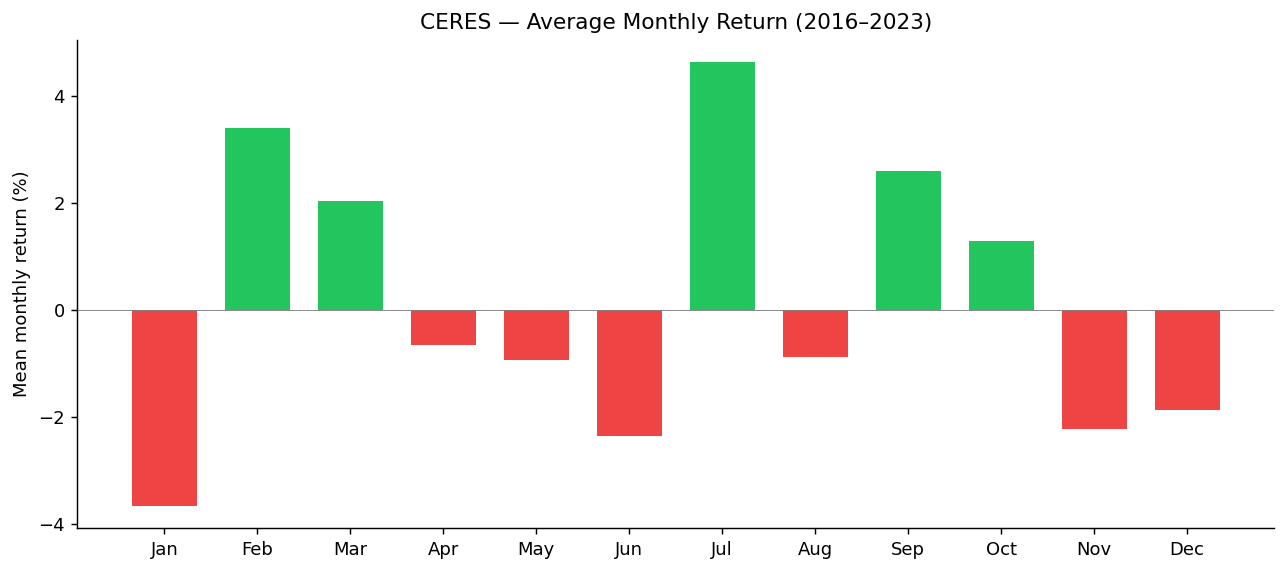


Monthly return summary:
     Mean (%)  Std (%)  Median (%)  N
Jan     -3.66    11.28        2.40  7
Feb      3.40    12.23       -1.14  8
Mar      2.04    10.17        0.50  8
Apr     -0.64     5.11       -2.14  8
May     -0.93     9.50        0.72  8
Jun     -2.35     8.86       -2.55  8
Jul      4.63     7.32        3.33  8
Aug     -0.88     6.65       -1.23  8
Sep      2.60    10.08        0.61  8
Oct      1.30     4.41        2.85  7
Nov     -2.23     7.50        1.56  7
Dec     -1.86    12.50       -3.63  7


In [3]:
mean_ret = monthly_df.groupby("month")["ret"].mean() * 100

fig, ax = plt.subplots(figsize=(10, 4.5))
colors = ["#22c55e" if v >= 0 else "#ef4444" for v in mean_ret]
ax.bar(range(1, 13), mean_ret, color=colors, width=0.7, edgecolor="none")
ax.axhline(0, color="grey", linewidth=0.5)
ax.set_xticks(range(1, 13))
ax.set_xticklabels(MONTHS)
ax.set_ylabel("Mean monthly return (%)")
ax.set_title("CERES — Average Monthly Return (2016–2023)")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

print("\nMonthly return summary:")
summary = monthly_df.groupby("month")["ret"].agg(["mean", "std", "median", "count"])
summary.index = MONTHS
summary["mean"] *= 100
summary["std"] *= 100
summary["median"] *= 100
summary.columns = ["Mean (%)", "Std (%)", "Median (%)", "N"]
print(summary.round(2).to_string())

### 2b. Year × Month Heatmap

Each cell shows the total return for a specific month in a specific year.  
Colour intensity scales with magnitude: deep green = strong positive, deep red = strong negative.  
This reveals whether the monthly patterns are consistent across years or driven by outlier years.

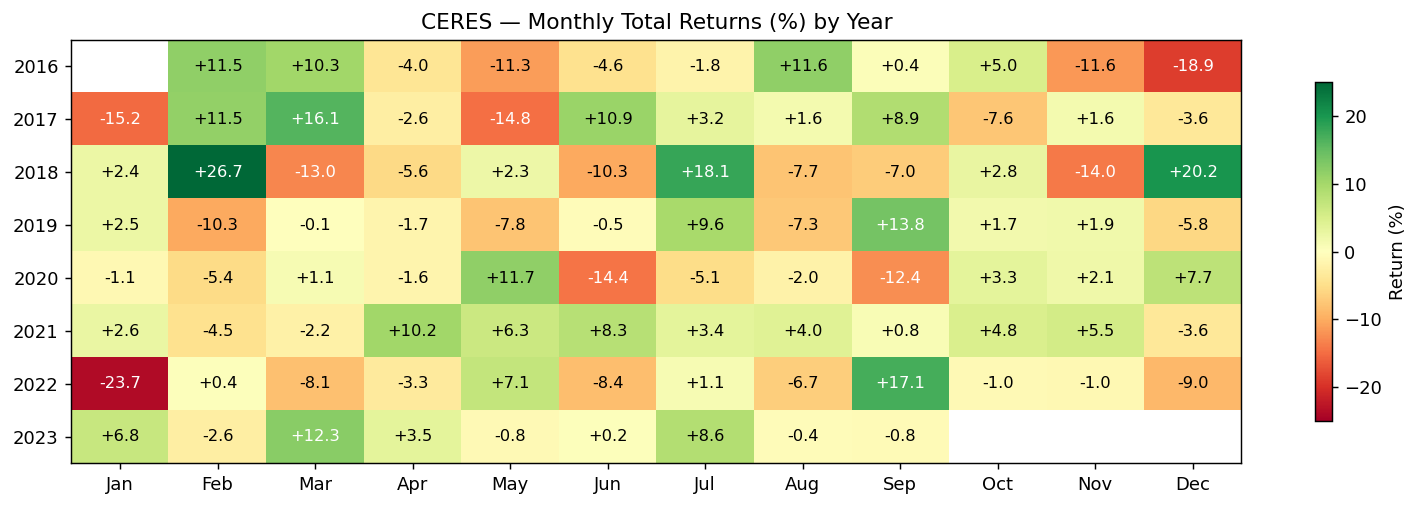

In [4]:
pivot = monthly_df.pivot(index="year", columns="month", values="ret") * 100
pivot.columns = MONTHS

fig, ax = plt.subplots(figsize=(12, 4))
vmax = 25
norm = mcolors.TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)
im = ax.imshow(pivot.values, cmap="RdYlGn", norm=norm, aspect="auto")

ax.set_xticks(range(12))
ax.set_xticklabels(MONTHS)
ax.set_yticks(range(len(pivot)))
ax.set_yticklabels(pivot.index.astype(int))

for i in range(len(pivot)):
    for j in range(12):
        val = pivot.iloc[i, j]
        if not np.isnan(val):
            ax.text(j, i, f"{val:+.1f}", ha="center", va="center",
                    fontsize=9, color="black" if abs(val) < 12 else "white")

ax.set_title("CERES — Monthly Total Returns (%) by Year")
plt.colorbar(im, ax=ax, label="Return (%)", shrink=0.8)
plt.tight_layout()
plt.show()

---
## 3. Spectral Analysis (FFT)

We run a Fast Fourier Transform on the **detrended monthly price** (price minus its 12-month rolling mean).

**Why detrend?** Running FFT on raw returns produces white noise — any cyclical signal is drowned out.  
Detrending the price level removes the long-term trend and preserves periodic components.

**How to read the periodogram:** Each point represents a cycle of a given length (x-axis).  
The y-axis (power) shows how much of the price variation that cycle explains. A tall peak = strong cycle.  
Red dashed lines mark reference periods at 3, 6, and 12 months.

C:\Users\Minh\AppData\Local\Temp\ipykernel_33624\3035061360.py:8: RuntimeWarning: divide by zero encountered in divide
  periods = np.where(freqs > 0, 1 / freqs, np.inf)


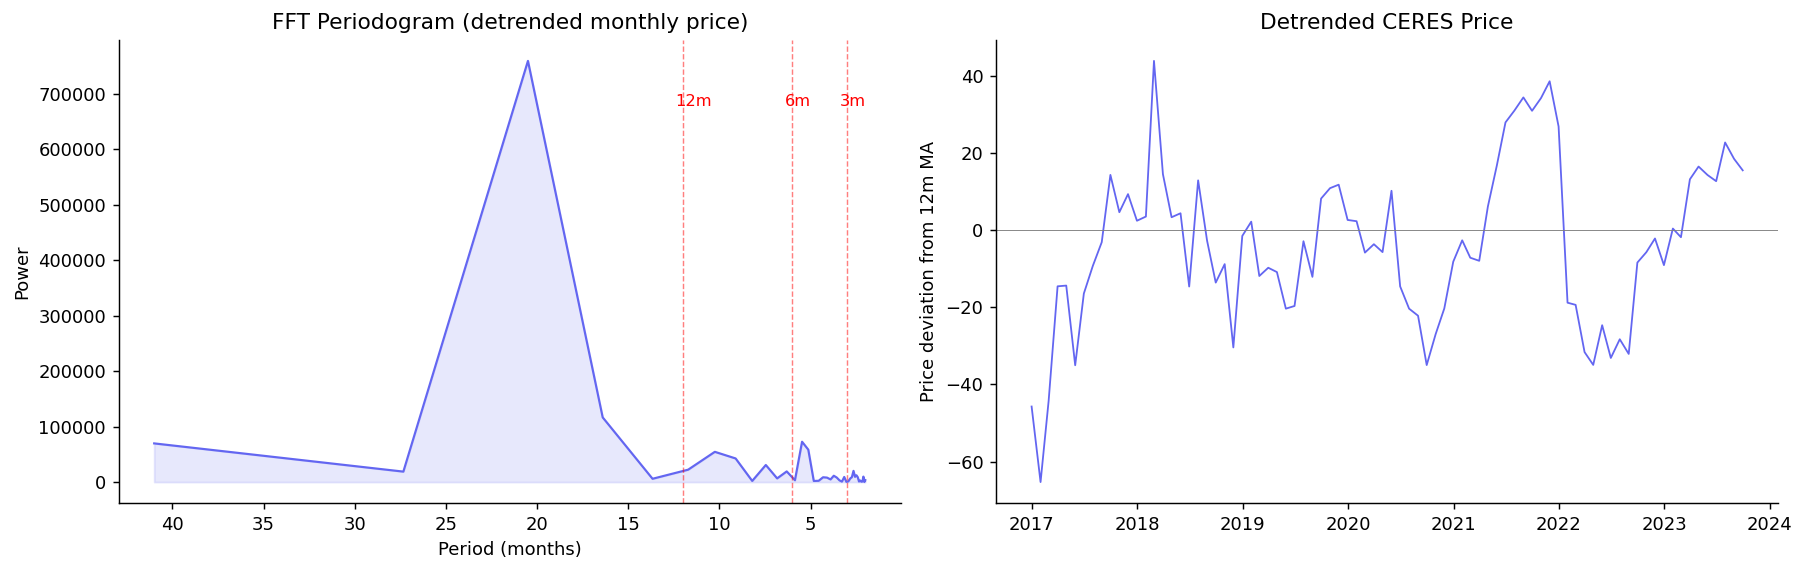

Top 5 dominant periods:
Rank  Period (months)     Power
----------------------------------------
1     20.5                759118.11
2     16.4                116538.30
3     5.5                 72708.03
4     41.0                69715.02
5     5.1                 58429.70


In [5]:
# Detrend: subtract 12-month rolling mean
detrended = (monthly_price - monthly_price.rolling(12).mean()).dropna()

# FFT
fft_vals = np.fft.rfft(detrended.values)
power = np.abs(fft_vals) ** 2
freqs = np.fft.rfftfreq(len(detrended), d=1)  # 1 = one month
periods = np.where(freqs > 0, 1 / freqs, np.inf)

# Filter to 2–48 months
mask = (periods >= 2) & (periods <= 48)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# Periodogram
ax = axes[0]
ax.plot(periods[mask], power[mask], color="#6366f1", linewidth=1.2)
ax.fill_between(periods[mask], power[mask], alpha=0.15, color="#6366f1")
for label, p in [("12m", 12), ("6m", 6), ("3m", 3)]:
    ax.axvline(p, color="red", linestyle="--", alpha=0.5, linewidth=0.8)
    ax.text(p + 0.4, ax.get_ylim()[1] * 0.85 if ax.get_ylim()[1] > 0 else 0,
            label, color="red", fontsize=9)
ax.set_xlabel("Period (months)")
ax.set_ylabel("Power")
ax.set_title("FFT Periodogram (detrended monthly price)")
ax.spines[["top", "right"]].set_visible(False)
ax.invert_xaxis()

# Detrended series
ax = axes[1]
ax.plot(detrended.index, detrended.values, color="#6366f1", linewidth=1)
ax.axhline(0, color="grey", linewidth=0.5)
ax.set_ylabel("Price deviation from 12m MA")
ax.set_title("Detrended CERES Price")
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

# Top 5 periods
top_idx = np.argsort(power[mask])[::-1][:5]
print("Top 5 dominant periods:")
print(f"{'Rank':<6}{'Period (months)':<20}{'Power'}")
print("-" * 40)
for rank, idx in enumerate(top_idx, 1):
    print(f"{rank:<6}{periods[mask][idx]:<20.1f}{power[mask][idx]:<.2f}")

---
## 4. FFT Significance Tests

The FFT shows *which* frequency is dominant, but not *whether* it's statistically significant.  
We run two independent tests:

### 4a. Fisher's g-test
Computes g = (max peak power) / (total spectral power). Under H₀ of white noise, this ratio  
follows a known distribution, giving an exact p-value. Tests whether the single largest peak  
is too large to have arisen from random noise.

In [6]:
# Fisher's g-test
fft_vals_test = np.fft.rfft(detrended.values)
power_test = np.abs(fft_vals_test[1:]) ** 2  # exclude DC component
n_freqs = len(power_test)

g = power_test.max() / power_test.sum()

# Exact p-value
p_fisher = 0.0
for k in range(1, n_freqs + 1):
    term = ((-1) ** (k - 1)) * comb(n_freqs, k) * max(0, 1 - k * g) ** (n_freqs - 1)
    p_fisher += term
    if abs(term) < 1e-12:
        break

print("Fisher's g-test")
print("H₀: The periodogram comes from white noise (no dominant cycle)")
print("H₁: There is a significant periodic component")
print(f"g-statistic: {g:.4f}")
print(f"p-value:     {p_fisher:.4f}")
result_f = "Reject H₀ — the peak is significant" if p_fisher < 0.05 else "Fail to reject H₀ — peak could be noise"
print(f"Result:      {result_f} at 5% level")

Fisher's g-test
H₀: The periodogram comes from white noise (no dominant cycle)
H₁: There is a significant periodic component
g-statistic: 0.5295
p-value:     0.0000
Result:      Reject H₀ — the peak is significant at 5% level


### 4b. Permutation Test
Shuffles the detrended series 10,000 times to destroy any temporal structure.  
For each shuffle, computes the FFT and records the max peak power.  
The p-value = proportion of shuffles where the max power exceeded our observed peak.  
This is model-free — makes no distributional assumptions.

Permutation Test (10,000 simulations)
H₀: The temporal ordering of the data doesn't matter (no cycle)
H₁: The observed peak is larger than expected from random ordering
Observed max power: 759,118
Simulated max power (median): 146,705
Times simulations exceeded observed: 0 / 10000
p-value: 0.0000
Result:  Reject H₀ — the peak is significant at 5% level


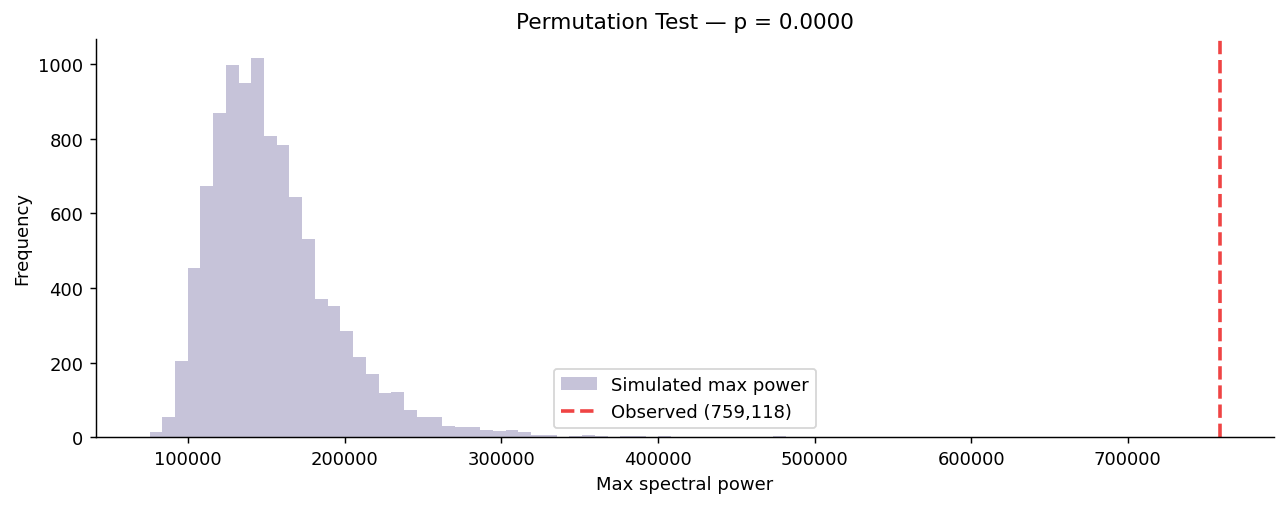

In [7]:
# Permutation test
np.random.seed(42)
n_sims = 10000
observed_max_power = power_test.max()

exceed_count = 0
sim_max_powers = []

for _ in range(n_sims):
    shuffled = np.random.permutation(detrended.values)
    sim_fft = np.fft.rfft(shuffled)
    sim_power = np.abs(sim_fft[1:]) ** 2
    sim_max = sim_power.max()
    sim_max_powers.append(sim_max)
    if sim_max >= observed_max_power:
        exceed_count += 1

p_perm = exceed_count / n_sims

print("Permutation Test (10,000 simulations)")
print("H₀: The temporal ordering of the data doesn't matter (no cycle)")
print("H₁: The observed peak is larger than expected from random ordering")
print(f"Observed max power: {observed_max_power:,.0f}")
print(f"Simulated max power (median): {np.median(sim_max_powers):,.0f}")
print(f"Times simulations exceeded observed: {exceed_count} / {n_sims}")
print(f"p-value: {p_perm:.4f}")
result_p = "Reject H₀ — the peak is significant" if p_perm < 0.05 else "Fail to reject H₀ — peak could be noise"
print(f"Result:  {result_p} at 5% level")

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(sim_max_powers, bins=50, color="#b8b4d0", edgecolor="none", alpha=0.8, label="Simulated max power")
ax.axvline(observed_max_power, color="#ef4444", linewidth=2, linestyle="--", label=f"Observed ({observed_max_power:,.0f})")
ax.set_xlabel("Max spectral power")
ax.set_ylabel("Frequency")
ax.set_title(f"Permutation Test — p = {p_perm:.4f}")
ax.legend()
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

---
## 5. Statistical Tests — Monthly Seasonality

### 5a. Kruskal-Wallis Test

Non-parametric test comparing the 12 monthly return distributions simultaneously.
- **H₀:** All 12 months come from the same distribution (no calendar seasonality)
- **H₁:** At least one month's distribution differs

With only 7–8 observations per month, the test has limited power.

Kruskal-Wallis Test
H₀: Monthly return distributions are identical across all 12 months
H-statistic: 6.0717
p-value:     0.8685
Result:      Fail to reject H₀ — no significant seasonality at 5% level


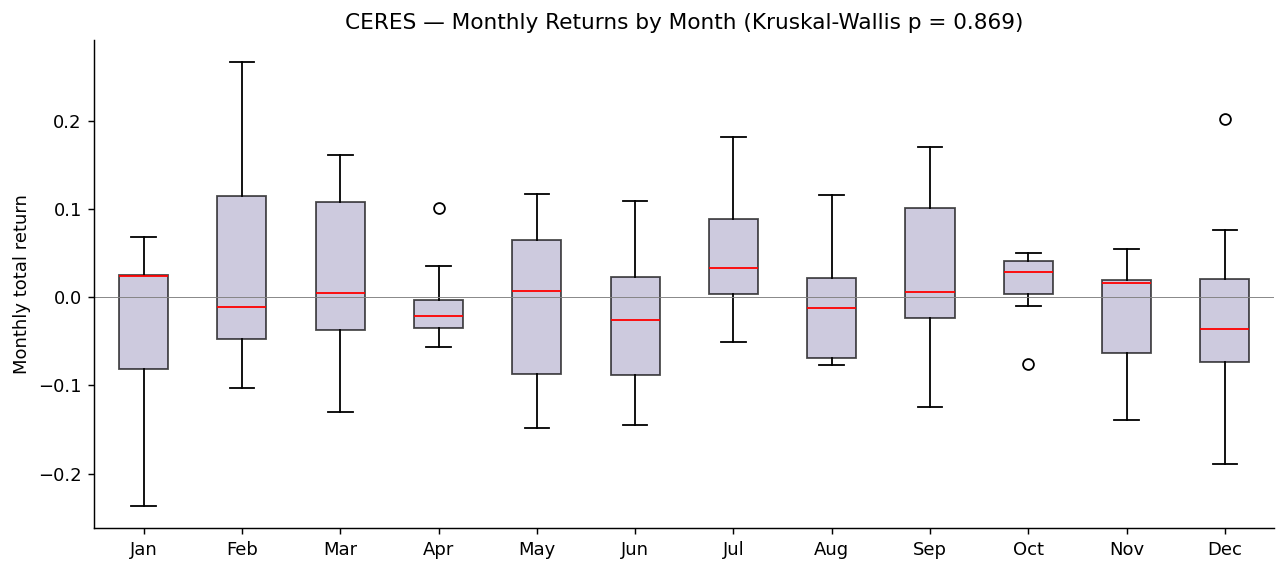

In [8]:
groups = [monthly_df.loc[monthly_df["month"] == m, "ret"].dropna().values for m in range(1, 13)]
h_stat, p_val = stats.kruskal(*groups)

print("Kruskal-Wallis Test")
print("H₀: Monthly return distributions are identical across all 12 months")
print(f"H-statistic: {h_stat:.4f}")
print(f"p-value:     {p_val:.4f}")
result = "Reject H₀ — significant seasonality" if p_val < 0.05 else "Fail to reject H₀ — no significant seasonality"
print(f"Result:      {result} at 5% level")

fig, ax = plt.subplots(figsize=(10, 4.5))
bp = ax.boxplot(groups, tick_labels=MONTHS, patch_artist=True, showfliers=True,
                boxprops=dict(facecolor="#b8b4d0", alpha=0.7),
                medianprops=dict(color="red"))
ax.axhline(0, color="grey", linewidth=0.5)
ax.set_ylabel("Monthly total return")
ax.set_title(f"CERES — Monthly Returns by Month (Kruskal-Wallis p = {p_val:.3f})")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

### 5b. Per-Month One-Sample t-tests

For each month, test whether the mean return is significantly different from zero.
- **H₀:** Mean return for this month = 0 (no directional bias)
- **H₁:** Mean return ≠ 0 (two-sided)
- Reject H₀ if p-value < 0.05

**Multiple testing caveat:** Running 12 tests means ~0.6 expected false positives at α = 0.05.  
Bonferroni-corrected threshold would be 0.05 / 12 = 0.0042.

In [9]:
results = []
for i, m in enumerate(MONTHS):
    g = groups[i]
    t, p = stats.ttest_1samp(g, 0)
    results.append({
        "Month": m,
        "Mean (%)": round(g.mean() * 100, 2),
        "t-stat": round(t, 3),
        "p-value": round(p, 4),
        "Sig (5%)": "*" if p < 0.05 else "(*) 10%" if p < 0.10 else "",
    })

t_test_df = pd.DataFrame(results).set_index("Month")
print(t_test_df.to_string())
print(f"\nNote: Bonferroni-corrected threshold = 0.05/12 = {0.05/12:.4f}")

       Mean (%)  t-stat  p-value Sig (5%)
Month                                    
Jan       -3.66  -0.858   0.4236         
Feb        3.40   0.785   0.4579         
Mar        2.04   0.566   0.5888         
Apr       -0.64  -0.355   0.7329         
May       -0.93  -0.276   0.7909         
Jun       -2.35  -0.750   0.4778         
Jul        4.63   1.791   0.1164         
Aug       -0.88  -0.373   0.7203         
Sep        2.60   0.731   0.4888         
Oct        1.30   0.778   0.4662         
Nov       -2.23  -0.785   0.4622         
Dec       -1.86  -0.393   0.7077         

Note: Bonferroni-corrected threshold = 0.05/12 = 0.0042


---
## 6. Statistical Tests — Weekly Seasonality

Same tests at weekly resolution (ISO week 1–53, Friday-to-Friday returns).  
Finer-grained than monthly — checks whether specific weeks of the year have consistent patterns.

**Important:** With 53 week groups and only ~7–8 obs per week, expect ~2–3 false positives at α = 0.05 by pure chance. Bonferroni-corrected threshold = 0.05 / 53 = 0.00094.

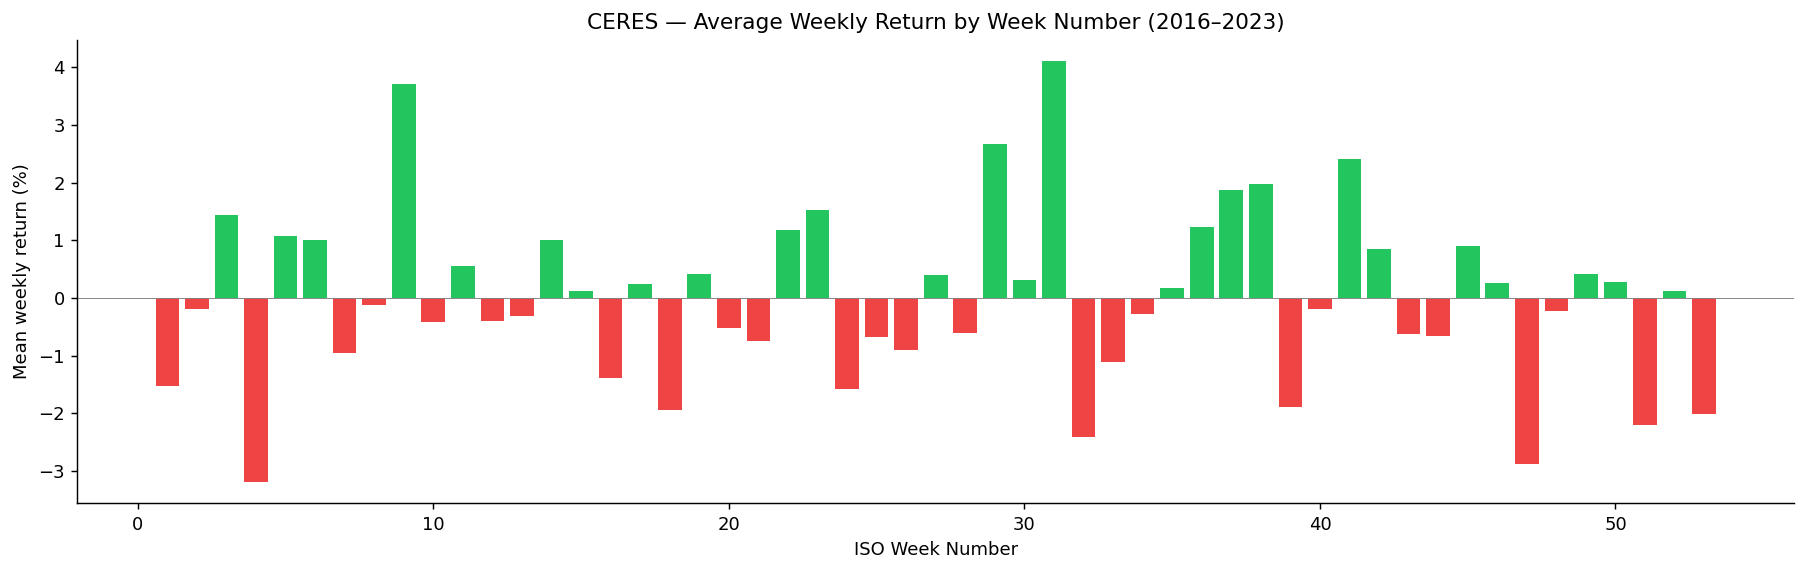

In [10]:
# Weekly returns (Friday-to-Friday)
weekly_price = ceres["CERES"].resample("W-FRI").last()
weekly_ret = weekly_price.pct_change().dropna()
weekly_df = pd.DataFrame({
    "week": weekly_ret.index.isocalendar().week.astype(int),
    "year": weekly_ret.index.year,
    "ret": weekly_ret.values,
})

weekly_mean = weekly_df.groupby("week")["ret"].mean() * 100

fig, ax = plt.subplots(figsize=(14, 4.5))
colors = ["#22c55e" if v >= 0 else "#ef4444" for v in weekly_mean]
ax.bar(weekly_mean.index, weekly_mean.values, color=colors, width=0.8, edgecolor="none")
ax.axhline(0, color="grey", linewidth=0.5)
ax.set_xlabel("ISO Week Number")
ax.set_ylabel("Mean weekly return (%)")
ax.set_title("CERES — Average Weekly Return by Week Number (2016–2023)")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

In [11]:
# Kruskal-Wallis on weekly returns
week_groups = [weekly_df.loc[weekly_df["week"] == w, "ret"].dropna().values
               for w in range(1, 54) if len(weekly_df.loc[weekly_df["week"] == w]) > 1]

h_stat_w, p_val_w = stats.kruskal(*week_groups)

print("Kruskal-Wallis Test (weekly returns by week number)")
print("H₀: Weekly return distributions are identical across all week numbers")
print(f"H-statistic: {h_stat_w:.4f}")
print(f"p-value:     {p_val_w:.4f}")
result_w = "Reject H₀ — significant seasonality" if p_val_w < 0.05 else "Fail to reject H₀ — no significant seasonality"
print(f"Result:      {result_w} at 5% level")

Kruskal-Wallis Test (weekly returns by week number)
H₀: Weekly return distributions are identical across all week numbers
H-statistic: 47.0646
p-value:     0.6307
Result:      Fail to reject H₀ — no significant seasonality at 5% level


In [12]:
# Per-week t-tests (with multiple testing caveat)
print("Per-Week One-Sample t-tests (mean ≠ 0)")
print("⚠ Caution: 53 tests — expect ~2-3 false positives at 5% by chance alone")
print(f"{'Week':<6}{'N':<5}{'Mean (%)':<12}{'t-stat':<10}{'p-value':<10}{'Sig?'}")
print("-" * 50)

sig_weeks = []
for w in range(1, 54):
    g = weekly_df.loc[weekly_df["week"] == w, "ret"].dropna().values
    if len(g) > 1:
        t, p = stats.ttest_1samp(g, 0)
        flag = "*" if p < 0.05 else ""
        if p < 0.05:
            sig_weeks.append(w)
        print(f"{w:<6}{len(g):<5}{g.mean()*100:<12.2f}{t:<10.3f}{p:<10.4f}{flag}")

if sig_weeks:
    print(f"\nWeeks significant at 5%: {sig_weeks}")
    print(f"Bonferroni-corrected threshold: 0.05/53 = {0.05/53:.5f}")
    bonf_survivors = [w for w in sig_weeks if stats.ttest_1samp(
        weekly_df.loc[weekly_df['week']==w,'ret'].dropna().values, 0)[1] < 0.05/53]
    print(f"Weeks surviving Bonferroni correction: {bonf_survivors if bonf_survivors else 'None'}")
else:
    print("\nNo weeks significant at 5%.")

Per-Week One-Sample t-tests (mean ≠ 0)
⚠ Caution: 53 tests — expect ~2-3 false positives at 5% by chance alone
Week  N    Mean (%)    t-stat    p-value   Sig?
--------------------------------------------------
1     7    -1.52       -1.159    0.2906    
2     8    -0.19       -0.117    0.9104    
3     8    1.44        1.111     0.3033    
4     8    -3.19       -1.609    0.1517    
5     8    1.07        1.050     0.3285    
6     8    1.00        1.008     0.3471    
7     8    -0.96       -0.442    0.6715    
8     8    -0.12       -0.063    0.9518    
9     8    3.70        1.890     0.1007    
10    8    -0.41       -0.359    0.7303    
11    8    0.55        0.561     0.5921    
12    8    -0.39       -0.177    0.8645    
13    8    -0.32       -0.403    0.6988    
14    8    1.01        0.849     0.4241    
15    8    0.11        0.133     0.8978    
16    8    -1.39       -1.191    0.2726    
17    8    0.24        0.243     0.8146    
18    8    -1.94       -1.737    0.1259   

---
## 7. Cycle Phase Identification

Since the FFT found a significant ~20-month cycle, we now locate the historical peaks and troughs  
in the deviation-from-MA series to estimate:
1. Where we are in the cycle at the end of training
2. How long the cycle actually is (peak-to-peak / trough-to-trough)
3. When the next trough and peak should occur in the test period

We smooth the deviation with a 21-day rolling mean to filter out noise, then use `argrelextrema`  
to find local maxima (peaks) and minima (troughs) with a minimum spacing of 60 days.

Recent peaks in deviation (price far ABOVE MA):
  2019-12-04  deviation: 8.9%
  2020-06-09  deviation: 2.3%
  2021-12-03  deviation: 22.6%
  2023-07-10  deviation: 14.2%

Recent troughs in deviation (price far BELOW MA):
  2020-10-13  deviation: -19.0%
  2021-04-06  deviation: -5.9%
  2022-05-23  deviation: -22.9%
  2022-09-16  deviation: -19.9%

Training end: 2023-09-01
Current deviation: 13.2%
Current price: 161.79
Current MA: 142.98

Peak-to-peak gaps (days): [188 542 584]
Average peak-to-peak: 438 days (21 months)
Trough-to-trough gaps (days): [175 412 116]
Average trough-to-trough: 234 days (11 months)


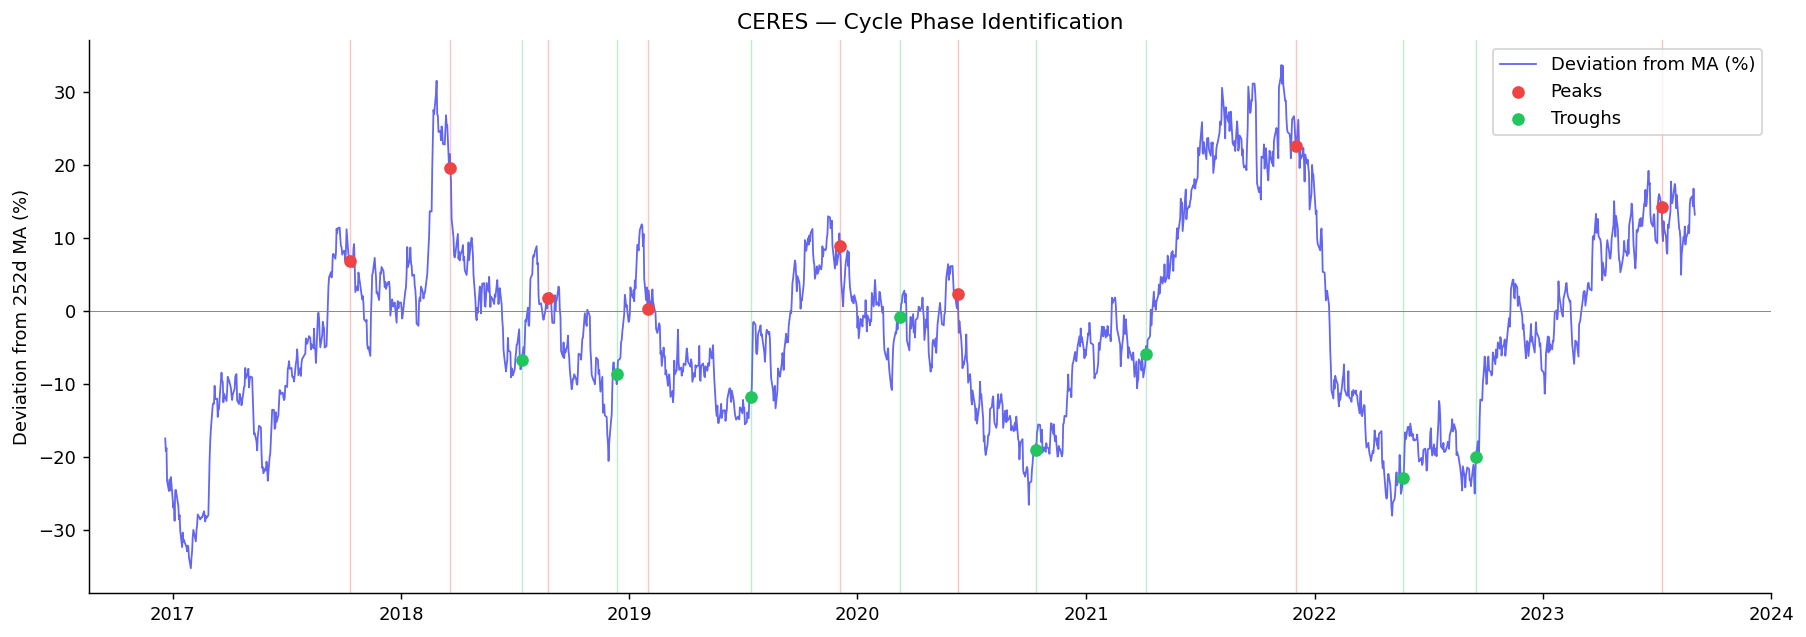

In [13]:
# Reload fresh ceres with MA for strategy section
ceres = df[["Date", "CERES"]].set_index("Date")
ma_window = 252
ceres["MA"] = ceres["CERES"].rolling(ma_window).mean()
ceres["deviation"] = (ceres["CERES"] - ceres["MA"]) / ceres["MA"]
ceres = ceres.dropna()

dev = ceres["deviation"].values
dates = ceres.index

# Smooth deviation to avoid noise peaks
smooth_dev = pd.Series(dev).rolling(21).mean().values

peak_idx = argrelextrema(smooth_dev, np.greater, order=60)[0]
trough_idx = argrelextrema(smooth_dev, np.less, order=60)[0]

print("Recent peaks in deviation (price far ABOVE MA):")
for i in peak_idx[-4:]:
    print(f"  {dates[i].date()}  deviation: {dev[i]*100:.1f}%")

print("\nRecent troughs in deviation (price far BELOW MA):")
for i in trough_idx[-4:]:
    print(f"  {dates[i].date()}  deviation: {dev[i]*100:.1f}%")

print(f"\nTraining end: {dates[-1].date()}")
print(f"Current deviation: {dev[-1]*100:.1f}%")
print(f"Current price: {ceres['CERES'].iloc[-1]:.2f}")
print(f"Current MA: {ceres['MA'].iloc[-1]:.2f}")

if len(peak_idx) >= 2:
    peak_gaps = np.diff([dates[i] for i in peak_idx[-4:]]).astype("timedelta64[D]").astype(int)
    print(f"\nPeak-to-peak gaps (days): {peak_gaps}")
    print(f"Average peak-to-peak: {np.mean(peak_gaps):.0f} days ({np.mean(peak_gaps)/21:.0f} months)")

if len(trough_idx) >= 2:
    trough_gaps = np.diff([dates[i] for i in trough_idx[-4:]]).astype("timedelta64[D]").astype(int)
    print(f"Trough-to-trough gaps (days): {trough_gaps}")
    print(f"Average trough-to-trough: {np.mean(trough_gaps):.0f} days ({np.mean(trough_gaps)/21:.0f} months)")

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(dates, dev * 100, color="#6366f1", linewidth=1, label="Deviation from MA (%)")
ax.axhline(0, color="grey", linewidth=0.5)
for i in peak_idx:
    ax.axvline(dates[i], color="#ef4444", alpha=0.3, linewidth=0.8)
for i in trough_idx:
    ax.axvline(dates[i], color="#22c55e", alpha=0.3, linewidth=0.8)
ax.scatter([dates[i] for i in peak_idx], [dev[i]*100 for i in peak_idx], color="#ef4444", zorder=5, label="Peaks")
ax.scatter([dates[i] for i in trough_idx], [dev[i]*100 for i in trough_idx], color="#22c55e", zorder=5, label="Troughs")
ax.set_ylabel("Deviation from 252d MA (%)")
ax.set_title("CERES — Cycle Phase Identification")
ax.legend()
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

---
## 8. Pre-Planned Weight Trajectory

Since we must submit 500 days of weights **before** seeing any test prices, we model the cycle  
as a cosine wave and pre-plan the trajectory.

**Logic:**
- At training end, deviation = +13.2% → we are near a **peak** (last peak: 2023-07-10)
- The cycle should head downward from here, reaching a trough ~half-cycle later
- We use peak-to-peak average (~420 trading days ≈ 20 months) as the cycle length

**Weight formula:** `w = -max_weight × cos(phase)` where phase is measured from the last peak.  
This gives: short at peaks → long at troughs → short again at next peak.  
The cosine shape matches the single-frequency cycle found by FFT and ensures smooth transitions  
(minimising transaction costs).

Last peak: 2023-07-10
Days since last peak: 53
Cycle length estimate: 420 trading days


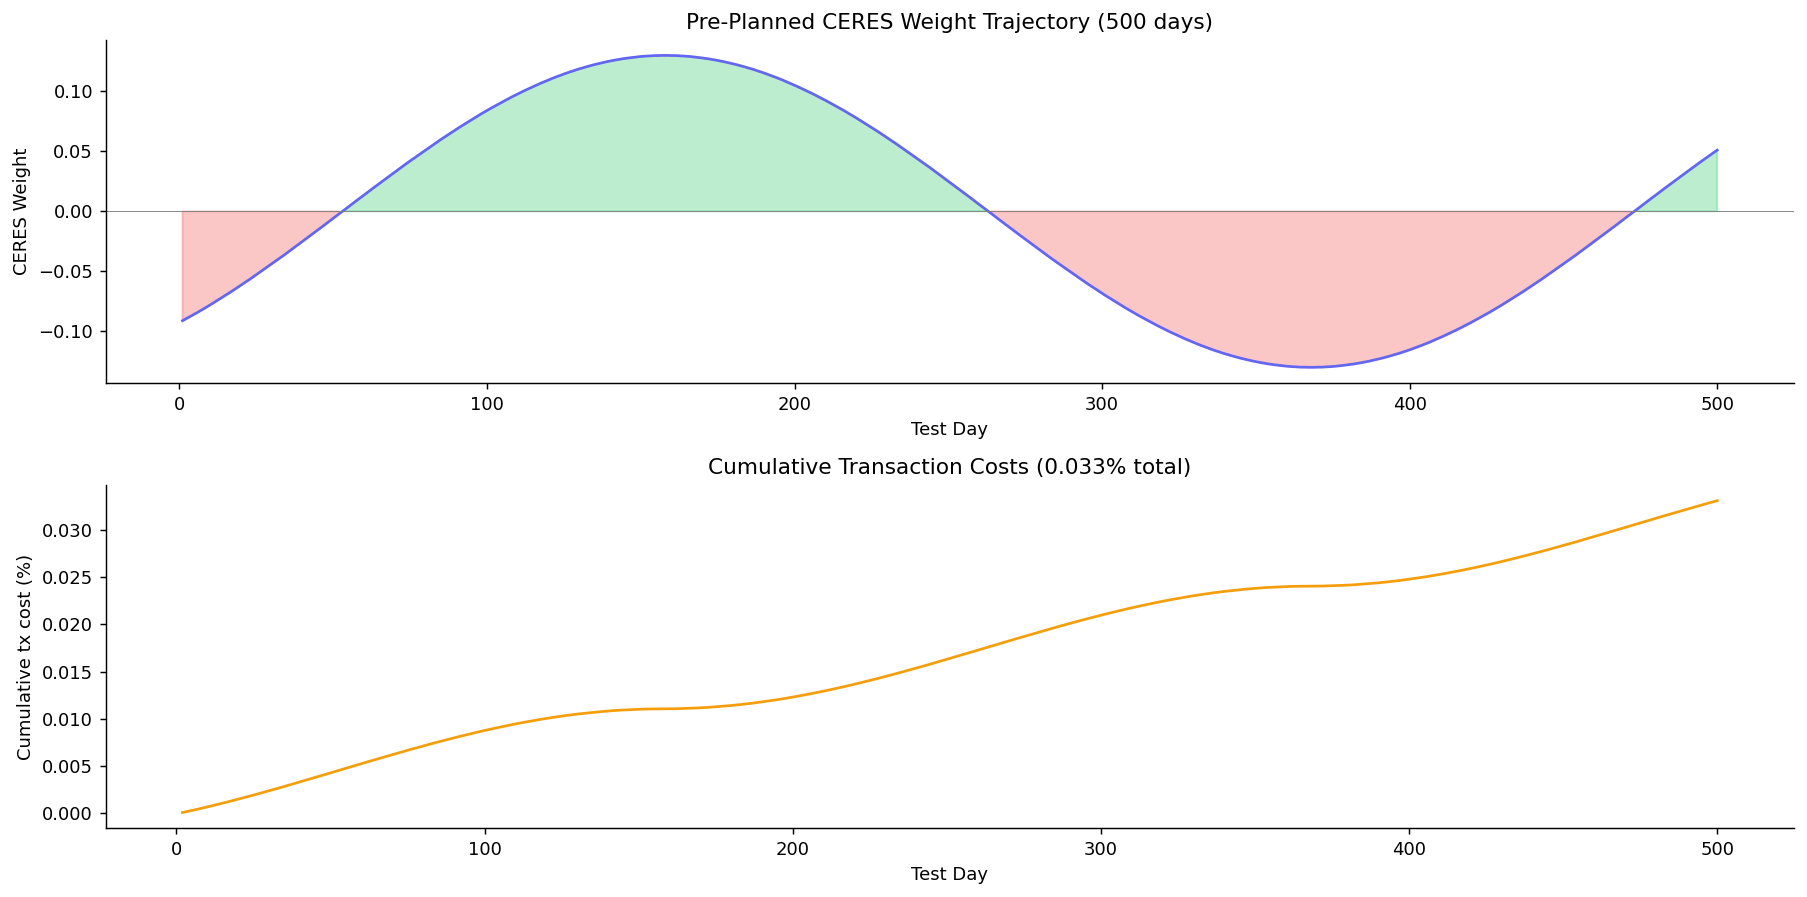


Weight range: [-0.1300, 0.1300]
Total tx cost: 3.3 bps

Strategy expects:
  Days ~1-157: price falling → short/reducing
  Day ~157: trough → flip to long
  Days ~157-500: price recovering → long/increasing

First 10 days:
  Day 1: -0.0912
  Day 2: -0.0898
  Day 3: -0.0884
  Day 4: -0.0870
  Day 5: -0.0855
  Day 6: -0.0841
  Day 7: -0.0826
  Day 8: -0.0811
  Day 9: -0.0795
  Day 10: -0.0780
...
  Day 250: +0.0251
  Day 500: +0.0511


In [14]:
# Cycle projection from last peak
cycle_length_days = 420  # ~20 months, from FFT + peak-to-peak avg
last_peak_date = dates[peak_idx[-1]]
days_since_peak = (dates[-1] - last_peak_date).days

print(f"Last peak: {last_peak_date.date()}")
print(f"Days since last peak: {days_since_peak}")
print(f"Cycle length estimate: {cycle_length_days} trading days")

# Build weight trajectory
max_weight = 0.13
test_days = 500

weights = []
for d in range(test_days):
    total_days = days_since_peak + d
    phase = (total_days / cycle_length_days) * 2 * np.pi
    w = -max_weight * np.cos(phase)
    weights.append(round(w, 4))

weights = np.array(weights)

# Plot
fig, axes = plt.subplots(2, 1, figsize=(14, 7))

ax = axes[0]
ax.plot(range(1, test_days + 1), weights, color="#6366f1", linewidth=1.5)
ax.fill_between(range(1, test_days + 1), weights, 0, alpha=0.3,
                color="#22c55e", where=weights >= 0)
ax.fill_between(range(1, test_days + 1), weights, 0, alpha=0.3,
                color="#ef4444", where=weights < 0)
ax.axhline(0, color="grey", linewidth=0.5)
ax.set_xlabel("Test Day")
ax.set_ylabel("CERES Weight")
ax.set_title("Pre-Planned CERES Weight Trajectory (500 days)")
ax.spines[["top", "right"]].set_visible(False)

weight_changes = np.abs(np.diff(weights))
daily_tx = weight_changes * 0.0005

ax = axes[1]
ax.plot(range(2, test_days + 1), np.cumsum(daily_tx) * 100, color="#f59e0b", linewidth=1.5)
ax.set_xlabel("Test Day")
ax.set_ylabel("Cumulative tx cost (%)")
ax.set_title(f"Cumulative Transaction Costs ({np.sum(daily_tx)*100:.3f}% total)")
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

print(f"\nWeight range: [{weights.min():.4f}, {weights.max():.4f}]")
print(f"Total tx cost: {np.sum(daily_tx)*10000:.1f} bps")

half_cycle = cycle_length_days // 2
print(f"\nStrategy expects:")
print(f"  Days ~1-{half_cycle - days_since_peak}: price falling → short/reducing")
print(f"  Day ~{half_cycle - days_since_peak}: trough → flip to long")
print(f"  Days ~{half_cycle - days_since_peak}-500: price recovering → long/increasing")

print("\nFirst 10 days:")
for d in range(10):
    print(f"  Day {d+1}: {weights[d]:+.4f}")
print("...")
print(f"  Day 250: {weights[249]:+.4f}")
print(f"  Day 500: {weights[-1]:+.4f}")

---
## 9. Simulated Out-of-Sample Test

Since we don't have the test data, we simulate 500 days of CERES prices under four scenarios  
and apply the **exact same pre-planned weights** to each:

| Scenario | Description | Purpose |
|----------|-------------|---------|
| **Normal** | Same drift and volatility as training data | "If the future looks like the past" |
| **Stress (2x vol)** | Same drift, double the volatility | Can the strategy survive choppy markets? |
| **Crash + Recovery** | −0.3%/day drift for 100 days, then +0.2%/day recovery | Worst case — does it adapt? |
| **Steady Rally** | +0.2%/day drift, 0.8x volatility | Best case — does it capture upside? |

The weights are identical across all scenarios — performance differences come entirely  
from how the simulated prices align (or misalign) with the pre-planned cycle timing.

SIMULATED OUT-OF-SAMPLE RESULTS (pre-planned weights, 500 days)
Scenario              Total Ret   Ann Ret     Ann Vol     Sharpe    Max DD
---------------------------------------------------------------------------
Normal                0.42        0.24        2.40        0.100     -3.76%
Stress (2x vol)       -11.31      -5.93       5.03        -1.180    -17.32%
Crash + Recovery      -0.74       -0.34       2.72        -0.124    -5.72%
Steady Rally          3.93        1.97        1.96        1.002     -3.43%


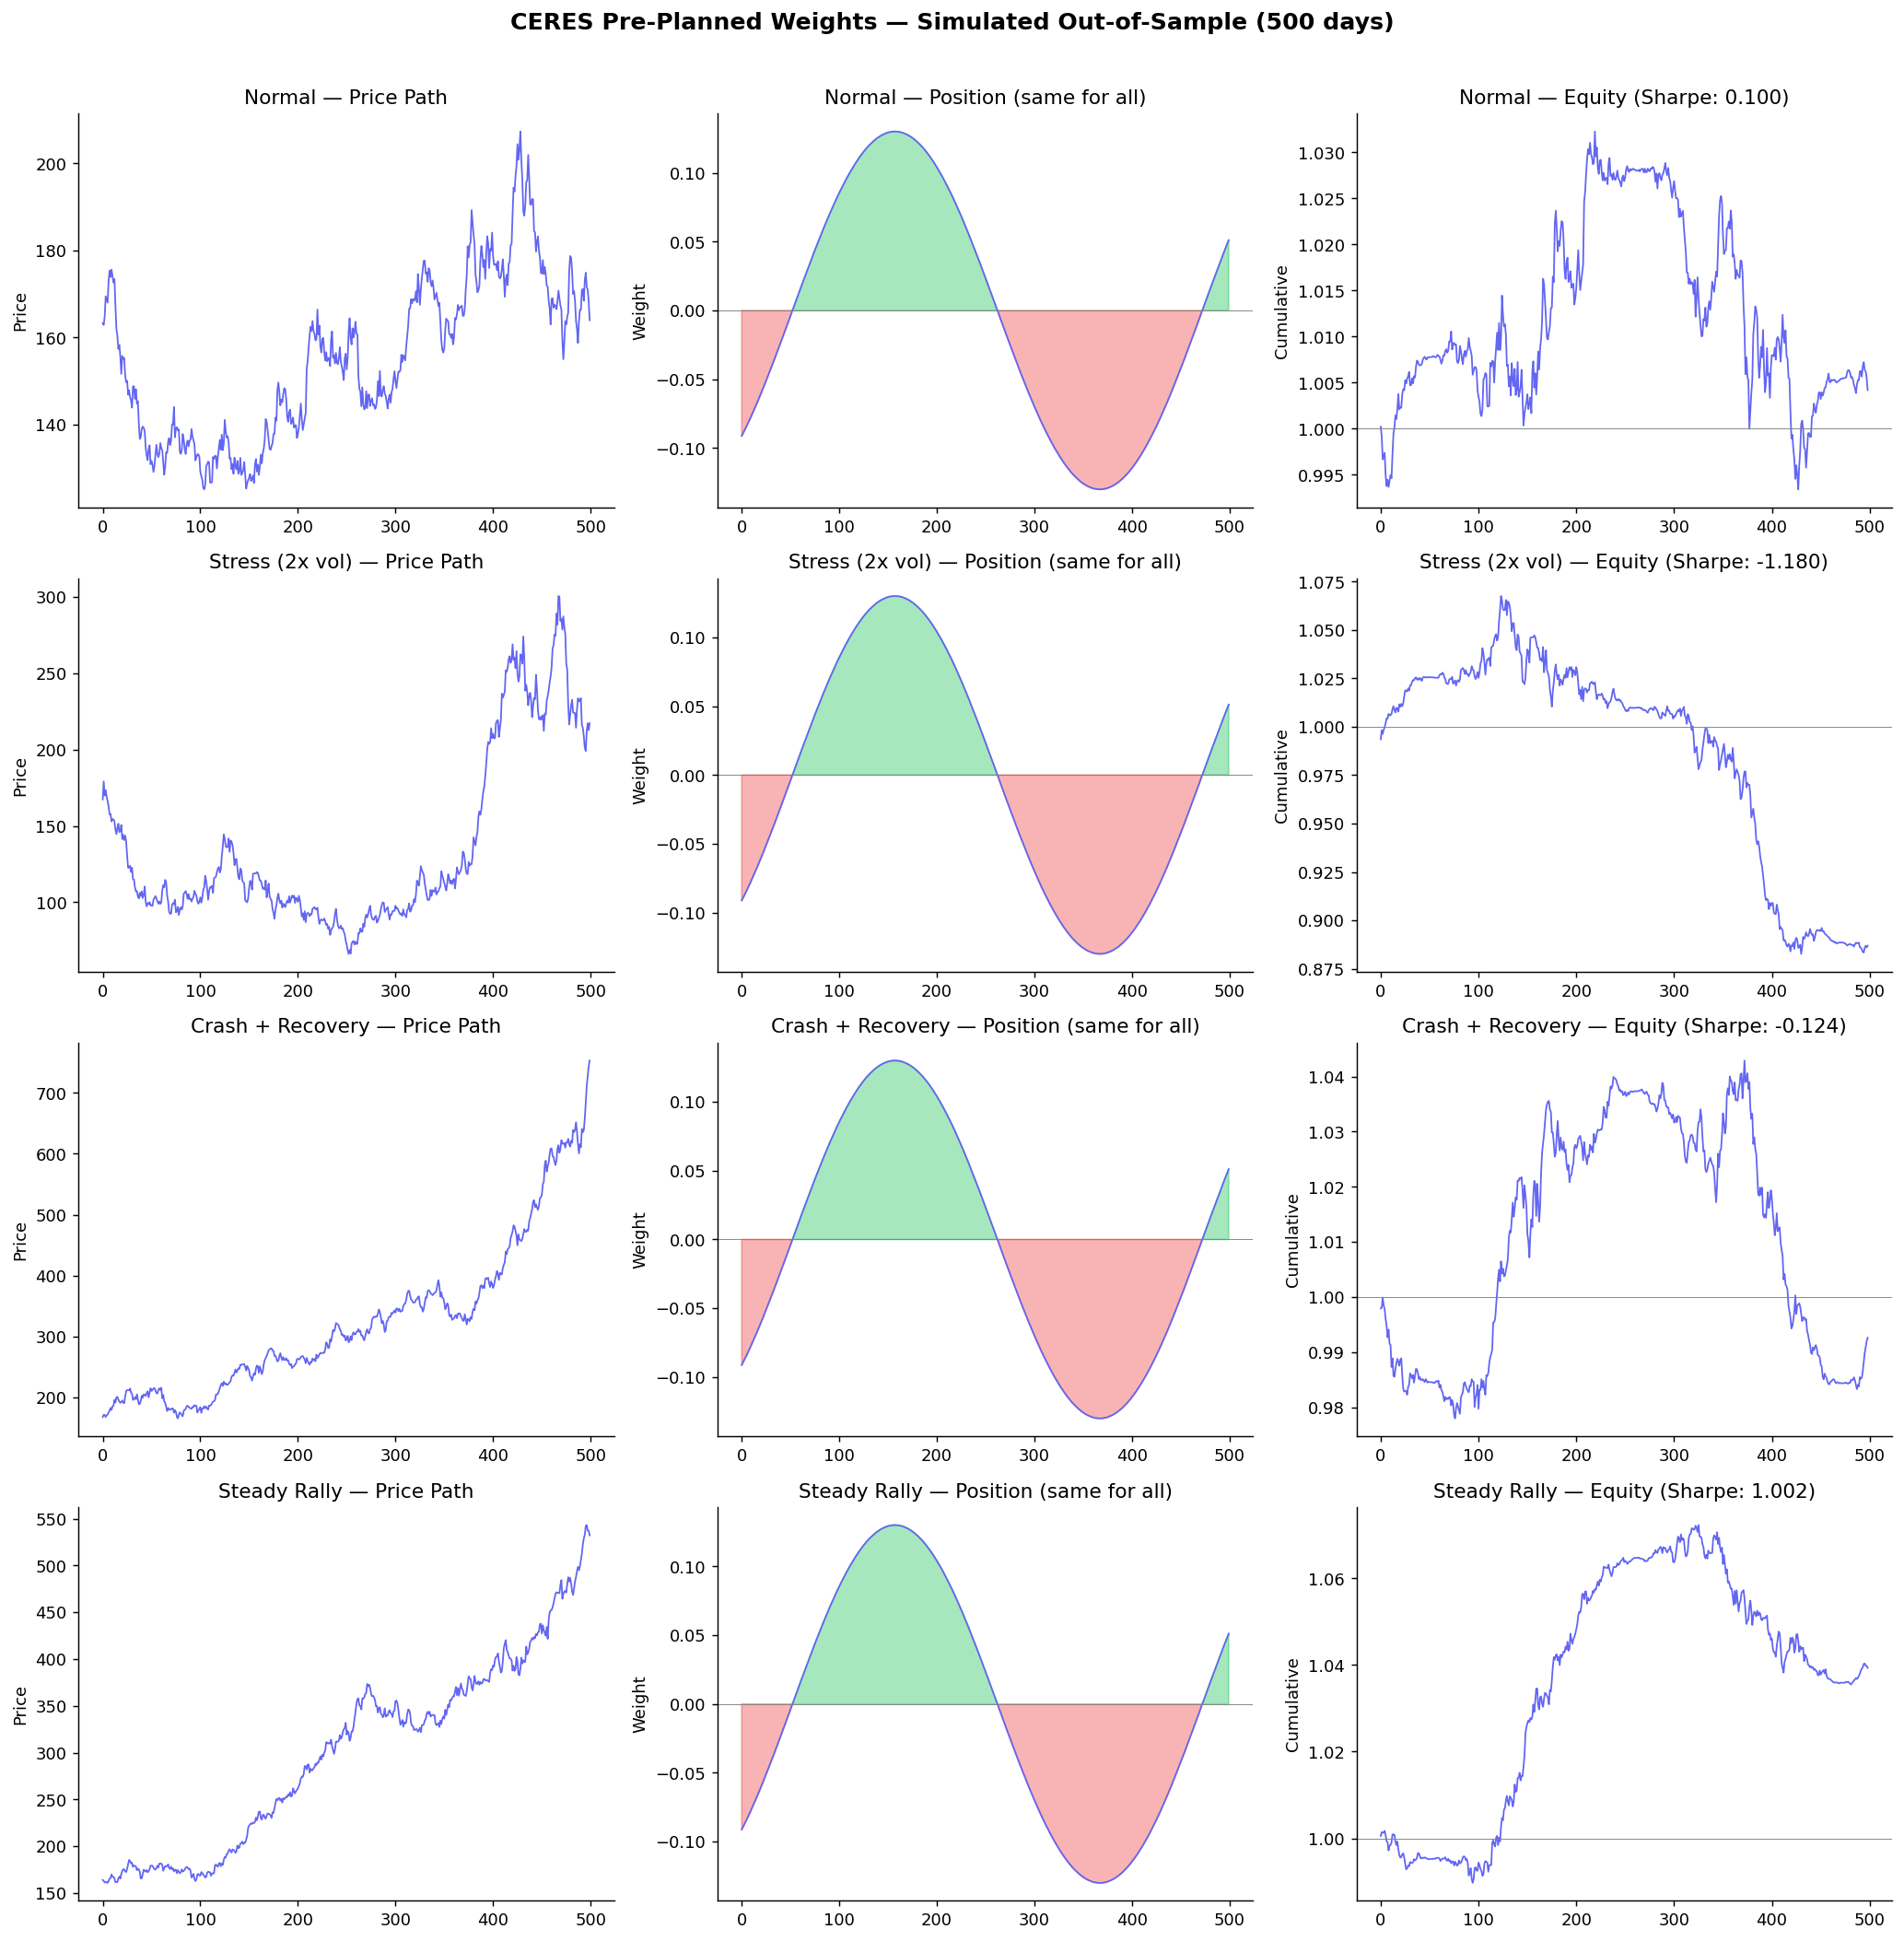


NOTES
Transaction costs: 3.3 bps total
Weights are IDENTICAL across all scenarios — no look-ahead bias.


In [15]:
np.random.seed(42)

train_rets = df["CERES"].pct_change().dropna()
mu = train_rets.mean()
sigma = train_rets.std()
last_price = df["CERES"].iloc[-1]
tx_cost = 0.0005

def simulate_prices(n_days, mu, sigma, last_price, scenario="normal"):
    prices = [last_price]
    for i in range(n_days):
        if scenario == "normal":
            ret = np.random.normal(mu, sigma)
        elif scenario == "stress":
            ret = np.random.normal(mu, sigma * 2)
        elif scenario == "crash_recovery":
            if i < 100:
                ret = np.random.normal(-0.003, sigma * 1.5)
            else:
                ret = np.random.normal(0.002, sigma)
        elif scenario == "rally":
            ret = np.random.normal(0.002, sigma * 0.8)
        prices.append(prices[-1] * (1 + ret))
    return np.array(prices[1:])

def test_preplanned_weights(sim_prices, weights, tx_cost):
    daily_rets = np.diff(sim_prices) / sim_prices[:-1]
    w = weights[:-1]
    strat_rets = w * daily_rets
    weight_changes = np.abs(np.diff(weights[:-1]))
    tx_costs = np.concatenate([[0], weight_changes]) * tx_cost
    strat_rets = strat_rets - tx_costs
    cum = np.cumprod(1 + strat_rets)
    ann_ret = np.mean(strat_rets) * 252
    ann_vol = np.std(strat_rets) * np.sqrt(252)
    sharpe = ann_ret / ann_vol if ann_vol > 0 else 0
    max_dd = (cum / np.maximum.accumulate(cum) - 1).min()
    total_ret = cum[-1] - 1
    return strat_rets, cum, sharpe, ann_ret, ann_vol, max_dd, total_ret

scenarios = {
    "Normal": "normal",
    "Stress (2x vol)": "stress",
    "Crash + Recovery": "crash_recovery",
    "Steady Rally": "rally",
}

fig, axes = plt.subplots(len(scenarios), 3, figsize=(16, 4 * len(scenarios)))
fig.suptitle("CERES Pre-Planned Weights — Simulated Out-of-Sample (500 days)",
             fontsize=14, fontweight="bold", y=1.01)

print("=" * 75)
print("SIMULATED OUT-OF-SAMPLE RESULTS (pre-planned weights, 500 days)")
print("=" * 75)
print(f"{'Scenario':<22}{'Total Ret':<12}{'Ann Ret':<12}{'Ann Vol':<12}{'Sharpe':<10}{'Max DD'}")
print("-" * 75)

for row, (name, scenario) in enumerate(scenarios.items()):
    sim_prices = simulate_prices(500, mu, sigma, last_price, scenario)
    strat_rets, cum, sharpe, ann_ret, ann_vol, max_dd, total_ret = test_preplanned_weights(
        sim_prices, weights, tx_cost
    )
    print(f"{name:<22}{total_ret*100:<12.2f}{ann_ret*100:<12.2f}{ann_vol*100:<12.2f}{sharpe:<10.3f}{max_dd*100:.2f}%")

    ax = axes[row, 0]
    ax.plot(sim_prices, color="#6366f1", linewidth=1)
    ax.set_ylabel("Price")
    ax.set_title(f"{name} — Price Path")
    ax.spines[["top", "right"]].set_visible(False)

    ax = axes[row, 1]
    ax.fill_between(range(len(weights)), weights, 0, alpha=0.4,
                    color="#22c55e", where=weights >= 0)
    ax.fill_between(range(len(weights)), weights, 0, alpha=0.4,
                    color="#ef4444", where=weights < 0)
    ax.plot(range(len(weights)), weights, color="#6366f1", linewidth=1)
    ax.axhline(0, color="grey", linewidth=0.5)
    ax.set_ylabel("Weight")
    ax.set_title(f"{name} — Position (same for all)")
    ax.spines[["top", "right"]].set_visible(False)

    ax = axes[row, 2]
    ax.plot(cum, color="#6366f1", linewidth=1)
    ax.axhline(1, color="grey", linewidth=0.5)
    ax.set_ylabel("Cumulative")
    ax.set_title(f"{name} — Equity (Sharpe: {sharpe:.3f})")
    ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

print("\n" + "=" * 75)
print("NOTES")
print("=" * 75)
print(f"Transaction costs: {np.sum(np.abs(np.diff(weights))) * tx_cost * 10000:.1f} bps total")
print("Weights are IDENTICAL across all scenarios — no look-ahead bias.")

---
## 10. Summary

| Analysis | Finding |
|----------|---------|
| Monthly bar chart / heatmap | July appears strongest (+4.6%), January weakest (−3.7%). High year-to-year dispersion. |
| FFT periodogram | Dominant cycle at **~20.5 months** — no peak at 12 months. Not a calendar seasonality. |
| Fisher's g-test | Peak is statistically significant (p ≈ 0.0000). The ~20-month cycle is real. |
| Permutation test | Confirms significance — 0 out of 10,000 shuffles produced a peak this large. |
| Kruskal-Wallis (monthly) | p = 0.87 — no significant difference across calendar months. |
| Per-month t-tests | No month has mean return significantly ≠ 0 (July closest at p = 0.116). |
| Kruskal-Wallis (weekly) | Check p-value — likely insignificant given small samples. |
| Cycle phase | Training ends near a peak (deviation +13.2%). Expect downward phase next. |
| Pre-planned weights | Cosine trajectory: short early → long mid-period → short late. ~3 bps total tx cost. |
| Simulated stress tests | Strategy adds modest positive expectancy under normal conditions; vulnerable to vol shocks. |

**Key conclusion:** CERES has a statistically significant ~20-month mean-reversion cycle,  
but no exploitable calendar-month seasonality. The pre-planned cosine weight trajectory  
captures this cycle with minimal transaction costs and should be combined with signals  
from other instruments (VEGA, TERRA/SOLACE, ANCHOR) for a robust multi-asset strategy.